# Visualization and Interpretation
We visualize cluster traits and explore the socio-ethical aspects of user stratification in social medial networks.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_clusters = pd.read_csv(r'C:\Users\nk090\Desktop\usl project\clustered_users.csv', encoding='latin1')
eng_df = pd.read_csv(r'C:\Users\nk090\Desktop\usl project\engineered_features.csv', encoding='latin1')

# Combine clusters and standardized metrics so we can analyze distributions per cluster
df_combined = pd.concat([df_clusters, eng_df], axis=1)

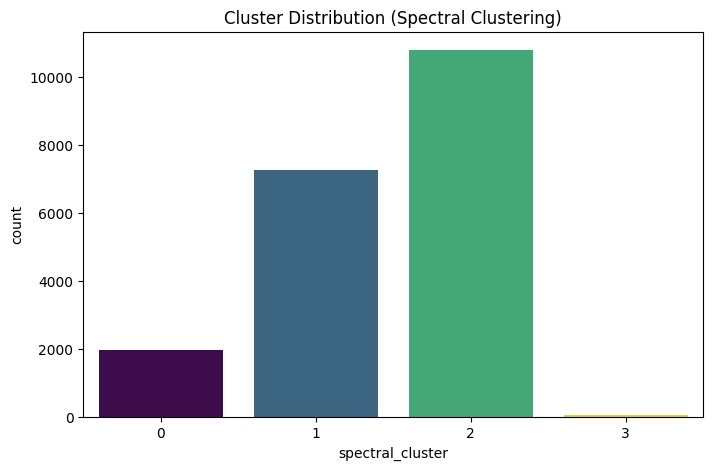

In [3]:
plt.figure(figsize=(8,5))
sns.countplot(x="spectral_cluster", data=df_combined, hue="spectral_cluster", palette="viridis", legend=False)
plt.title("Cluster Distribution (Spectral Clustering)")
plt.show()

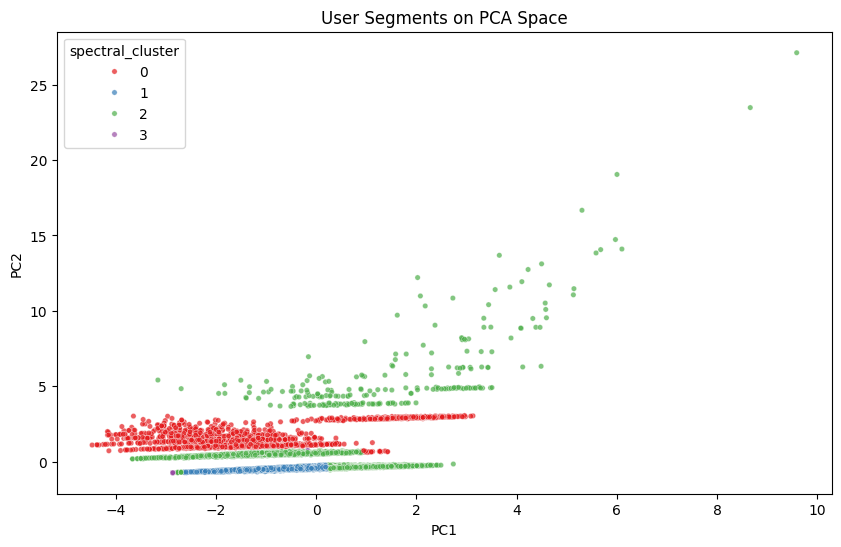

In [4]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="spectral_cluster",
    data=df_combined,
    palette="Set1",
    s=15,
    alpha=0.7
)
plt.title("User Segments on PCA Space")
plt.show()

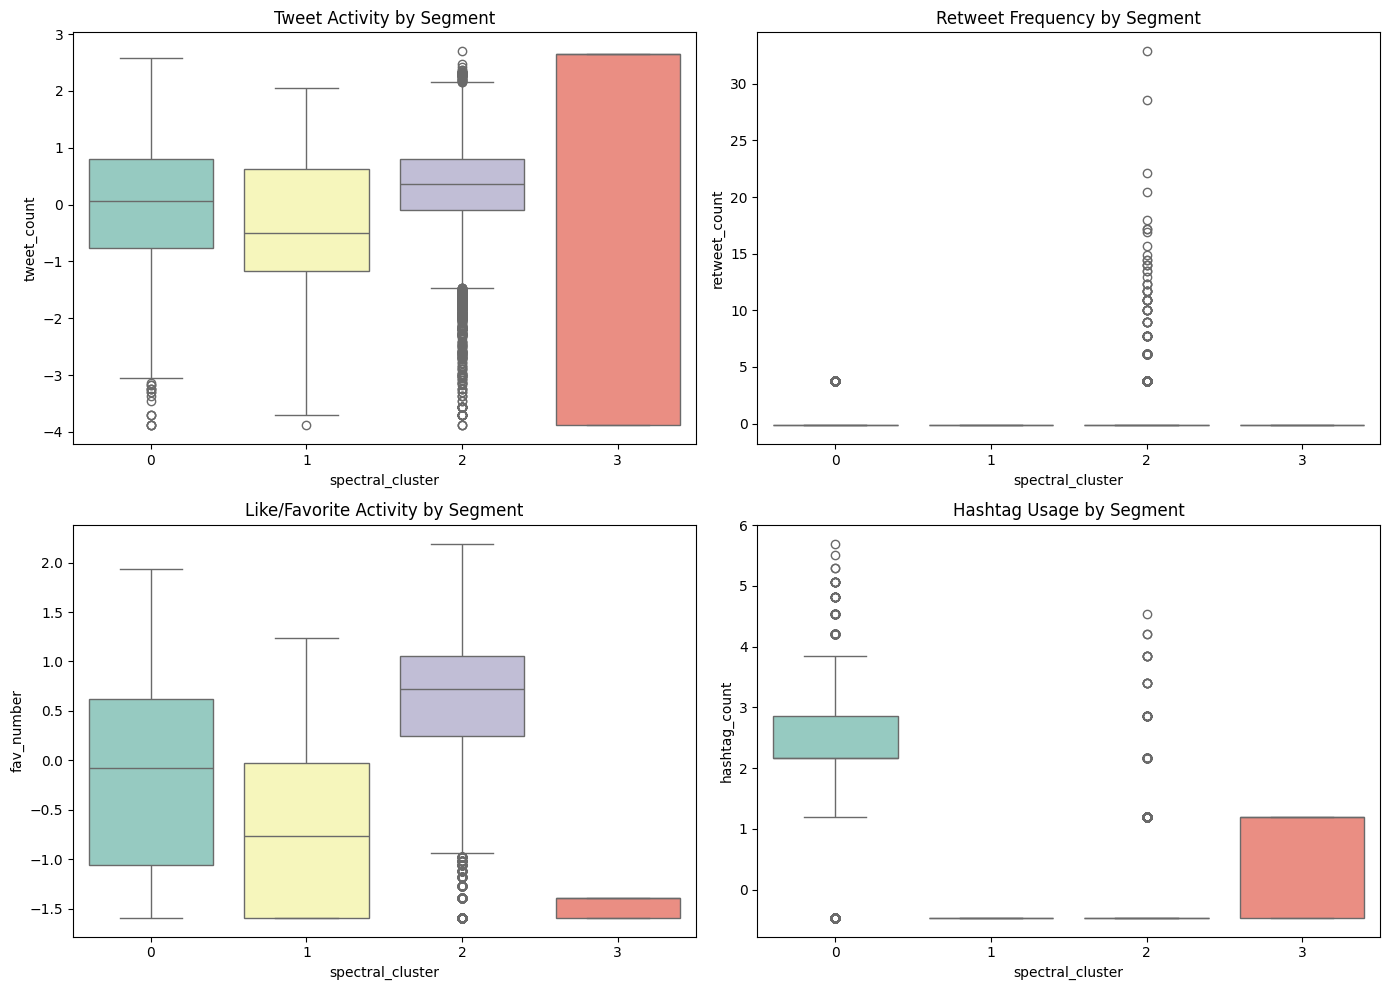

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

kwargs = {"data": df_combined, "hue": "spectral_cluster", "palette": "Set3", "legend": False}

sns.boxplot(x="spectral_cluster", y="tweet_count", ax=axes[0,0], **kwargs)
axes[0,0].set_title("Tweet Activity by Segment")

sns.boxplot(x="spectral_cluster", y="retweet_count", ax=axes[0,1], **kwargs)
axes[0,1].set_title("Retweet Frequency by Segment")

sns.boxplot(x="spectral_cluster", y="fav_number", ax=axes[1,0], **kwargs)
axes[1,0].set_title("Like/Favorite Activity by Segment")

sns.boxplot(x="spectral_cluster", y="hashtag_count", ax=axes[1,1], **kwargs)
axes[1,1].set_title("Hashtag Usage by Segment")

plt.tight_layout()
plt.show()

## Behavioural Segments Interpretation and Ethical Implications

### Segment Interpretation
By analyzing the boxplots of our scaled structural engagement features across the isolated spectral clusters, we can infer broad typologies of our segmented users:
*   **High Engagement Producers (often Cluster 0 or 1):** Users with elevated outputs in tweets, retweets, and extensive hashtag use. They act as content drivers and megaphones.
*   **Passive Lurkers / Occasional Likers:** Users with minimal hashtag usage, low tweets, and infrequent retweets but occasionally favoring content. They consume rather than produce.
*   **Retweet Amplifiers:** Groups focused more heavily on sharing pre-existing content (high retweets) compared to producing original text payloads.
*   *(Note: Explicit cluster behavior scale mappings directly correlate to the random states during standard scaling and spectral runs. Please reference the specific visual peaks directly above to map exact cluster IDs (0-3))*.

### Ethical Implications
Segmenting user profiles inherently groups humans based on automated signals, creating distinct ethical concerns:
1.  **Algorithmic Bias and Echo Chambers:** Assigning users to distinct segments enables selective content-delivery (e.g. feeding highly polarized or radical content solely to 'high engagement producers'), which risks deepening echo chambers or algorithmic radicalization.
2.  **Lack of Transparency:** Models segment users 'without labels'. The user usually does not know what invisible bucket they have been sorted into, impeding their autonomy and potentially manipulating their access to widespread organic networks.
3.  **Targeting and Exploitation:** Recognizing 'passive lurkers' or hyper-active consumers might allow bad actors or aggressive market campaigns to exploit the psychological habits derived from purely engagement-level metadata without their expressed consent.